## Leitura de Arquivo

In [1]:
import pandas as pd

csv_path = r"C:/Users/augus/Desktop/Projetos/youtubeCommentsAnalysis/assets/comments_data.csv"

df = pd.read_csv(csv_path)

df.head(10)

,comment
0,pesquisa fraudest
1,quer fraudar mais uma eleição
2,o congresso nacional manteve o brasil nestes ú...
3,é uma justiça bosta
4,sou aposentado que contribui no regime inss an...
5,tramp é um débil mental
6,como ele quer um código de ética sendo que o m...
7,eles só precisam obedecer e defender a constit...
8,que piada o que precisam é serem punidos por s...
9,não precisa disso já está na lei essas regrasm...


## Tratamento dos dados

In [2]:
df = df.drop_duplicates(subset="comment")

df["comment_clean"] = df["comment"].str.strip().str.lower()

df = df[df["comment_clean"] != ""]

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 84 entries, 0 to 86
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   comment        83 non-null     str  
 1   comment_clean  83 non-null     str  
dtypes: str(2)
memory usage: 2.0 KB


## Número médio de letras

In [4]:
df["num_letters"] = df["comment_clean"].apply(lambda x : len(str(x)))

media_letras = df['num_letters'].mean()
print(f'Número médio de letras: {int(media_letras)}\n')
df.info()

Número médio de letras: 195

<class 'pandas.DataFrame'>
Index: 84 entries, 0 to 86
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   comment        83 non-null     str  
 1   comment_clean  83 non-null     str  
 2   num_letters    84 non-null     int64
dtypes: int64(1), str(2)
memory usage: 2.6 KB


## 20 palavras mais comun

In [5]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\augus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
all_words = " ".join(df["comment_clean"].dropna().astype(str)).split()
filtered_words = [w for w in all_words if w not in stop_words]

word_counts = Counter(filtered_words)

print(word_counts.most_common(20))

[('vai', 14), ('pra', 10), ('mundo', 10), ('trânsito', 10), ('anos', 9), ('europa', 9), ('bicicleta', 9), ('todos', 8), ('guerra', 8), ('deus', 8), ('brasil', 7), ('agora', 7), ('todo', 7), ('trump', 7), ('tudo', 7), ('sempre', 7), ('ter', 7), ('vida', 7), ('quer', 6), ('nada', 6)]


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 84 entries, 0 to 86
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   comment        83 non-null     str  
 1   comment_clean  83 non-null     str  
 2   num_letters    84 non-null     int64
dtypes: int64(1), str(2)
memory usage: 2.6 KB


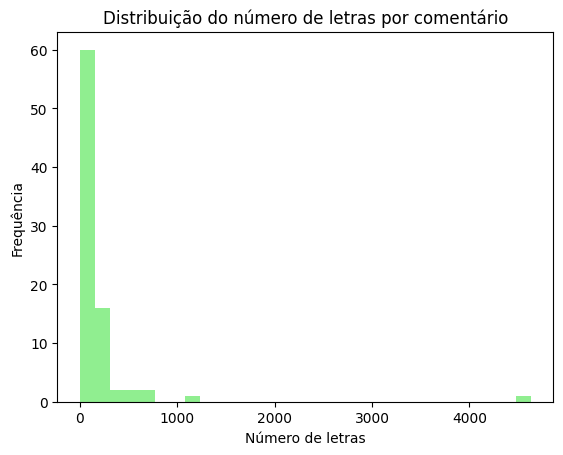

In [8]:
import matplotlib.pyplot as plt

plt.hist(df['num_letters'], bins=30, color='lightgreen')
plt.title('Distribuição do número de letras por comentário')
plt.xlabel('Número de letras')
plt.ylabel('Frequência')
plt.show()